# Step 2: Preprocessing & Model Training

Now that we understand our data, we'll:
1. Preprocess: scale Amount, drop Time
2. Split into train (normal only) and test (normal + fraud)
3. Train 5 unsupervised algorithms from the paper
4. Evaluate with accuracy, precision, recall, F1-score
5. Compare results

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from sklearn.svm import OneClassSVM
from sklearn.linear_model import SGDOneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
import time
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [4]:
df = pd.read_csv("../data/creditcard.csv")
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

Loaded: 284,807 rows x 31 columns


## 1. Preprocessing

Three things to do:
- **Drop `Time`** — it's just seconds since first transaction, not useful for anomaly patterns
- **Scale `Amount`** — it's on a completely different scale than V1-V28
- **Keep duplicates** — duplicate transactions can be legitimate

In [5]:
# Drop Time
df = df.drop(columns=["Time"])

# Scale Amount to match V1-V28 range
scaler = StandardScaler()
df["Amount"] = scaler.fit_transform(df[["Amount"]])

print(f"Amount after scaling: mean={df['Amount'].mean():.4f}, std={df['Amount'].std():.4f}")
print(f"Columns: {list(df.columns)}")
print(f"Shape: {df.shape}")

Amount after scaling: mean=-0.0000, std=1.0000
Columns: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
Shape: (284807, 30)


## 2. Train/Test Split

**Important concept:** In unsupervised anomaly detection, we train ONLY on normal data.  
The models learn what \"normal\" looks like, then anything that deviates = anomaly.

Strategy:
- **Train set:** 80% of normal data (no fraud at all)
- **Test set:** 20% of normal data + ALL fraud data

We use `Class` for evaluation only — the algorithms never see it during training.

In [6]:
# Separate normal and fraud
normal = df[df["Class"] == 0]
fraud = df[df["Class"] == 1]

print(f"Normal: {len(normal):,}")
print(f"Fraud:  {len(fraud):,}")

# Split normal data: 80% train, 20% test
X_normal = normal.drop(columns=["Class"])
X_fraud = fraud.drop(columns=["Class"])

X_train, X_test_normal = train_test_split(X_normal, test_size=0.2, random_state=42)

# Test set = normal test + all fraud
X_test = pd.concat([X_test_normal, X_fraud])
y_test = np.array([0] * len(X_test_normal) + [1] * len(X_fraud))

print(f"\nTrain set (normal only): {len(X_train):,}")
print(f"Test set: {len(X_test):,} ({len(X_test_normal):,} normal + {len(X_fraud):,} fraud)")

Normal: 284,315
Fraud:  492

Train set (normal only): 227,452
Test set: 57,355 (56,863 normal + 492 fraud)


## 3. Sampling for Expensive Algorithms

Our dataset has ~285K rows. Some algorithms (One-Class SVM, Elliptic Envelope, LOF)  
are very slow on large datasets.

We'll use a **subsample for training** the expensive algorithms, but test on the full test set.  
Isolation Forest and SGD-based SVM handle large data fine.

In [7]:
SAMPLE_SIZE = 10000
X_train_sample = X_train.sample(n=SAMPLE_SIZE, random_state=42)

print(f"Full training set: {len(X_train):,}")
print(f"Sampled training set: {len(X_train_sample):,} (for slow algorithms)")

Full training set: 227,452
Sampled training set: 10,000 (for slow algorithms)


## 4. Train the 5 Algorithms

Each algorithm learns what \"normal\" looks like, then predicts:
- `+1` = normal (inlier)
- `-1` = anomaly (outlier)

We convert these to match our labels: `0` = normal, `1` = fraud.

In [8]:
def convert_predictions(preds):
    """sklearn: -1=outlier, 1=normal  ->  our labels: 1=fraud, 0=normal"""
    return np.where(preds == -1, 1, 0)

# Store results
results = {}
timing = {}

### 4.1 One-Class SVM

Uses the kernel trick to find a boundary around normal data.  
Points outside the boundary = anomalies.  
**Slow** — using sampled training set.

In [9]:
print("Training One-Class SVM...")
start = time.time()

oc_svm = OneClassSVM(kernel="rbf", gamma=0.1, nu=0.01)
oc_svm.fit(X_train_sample)

fit_time = time.time() - start
start = time.time()

preds = convert_predictions(oc_svm.predict(X_test))

pred_time = time.time() - start
timing["One-Class SVM"] = {"fit": fit_time, "predict": pred_time}
results["One-Class SVM"] = preds

print(f"Done! Fit: {fit_time:.2f}s, Predict: {pred_time:.2f}s")
print(f"Predicted {preds.sum():,} anomalies out of {len(preds):,} test samples")

Training One-Class SVM...
Done! Fit: 0.66s, Predict: 5.52s
Predicted 8,543 anomalies out of 57,355 test samples


### 4.2 One-Class SVM with SGD

Same idea but uses Stochastic Gradient Descent — much faster, scales to large datasets.  
**Can use full training set.**

In [10]:
print("Training One-Class SVM with SGD...")
start = time.time()

sgd_svm = SGDOneClassSVM(nu=0.01, max_iter=1000, learning_rate="optimal", random_state=42)
sgd_svm.fit(X_train)

fit_time = time.time() - start
start = time.time()

preds = convert_predictions(sgd_svm.predict(X_test))

pred_time = time.time() - start
timing["One-Class SVM (SGD)"] = {"fit": fit_time, "predict": pred_time}
results["One-Class SVM (SGD)"] = preds

print(f"Done! Fit: {fit_time:.2f}s, Predict: {pred_time:.2f}s")
print(f"Predicted {preds.sum():,} anomalies out of {len(preds):,} test samples")

Training One-Class SVM with SGD...
Done! Fit: 1.36s, Predict: 0.02s
Predicted 0 anomalies out of 57,355 test samples


### 4.3 Isolation Forest

Isolates anomalies using random trees. Anomalies need fewer splits to isolate.  
**Handles large datasets well** — using full training set.

In [11]:
print("Training Isolation Forest...")
start = time.time()

iforest = IsolationForest(n_estimators=100, contamination=0.01, max_samples="auto", random_state=42)
iforest.fit(X_train)

fit_time = time.time() - start
start = time.time()

preds = convert_predictions(iforest.predict(X_test))

pred_time = time.time() - start
timing["Isolation Forest"] = {"fit": fit_time, "predict": pred_time}
results["Isolation Forest"] = preds

print(f"Done! Fit: {fit_time:.2f}s, Predict: {pred_time:.2f}s")
print(f"Predicted {preds.sum():,} anomalies out of {len(preds):,} test samples")

Training Isolation Forest...
Done! Fit: 1.40s, Predict: 0.29s
Predicted 857 anomalies out of 57,355 test samples


### 4.4 Local Outlier Factor (LOF)

Compares the local density of a point to its neighbors.  
Points with much lower density = anomalies.  
**Slow** — using sampled training set.

In [12]:
print("Training Local Outlier Factor...")
start = time.time()

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.01, novelty=True)
lof.fit(X_train_sample)

fit_time = time.time() - start
start = time.time()

preds = convert_predictions(lof.predict(X_test))

pred_time = time.time() - start
timing["Local Outlier Factor"] = {"fit": fit_time, "predict": pred_time}
results["Local Outlier Factor"] = preds

print(f"Done! Fit: {fit_time:.2f}s, Predict: {pred_time:.2f}s")
print(f"Predicted {preds.sum():,} anomalies out of {len(preds):,} test samples")

Training Local Outlier Factor...
Done! Fit: 0.35s, Predict: 0.86s
Predicted 943 anomalies out of 57,355 test samples


### 4.5 Robust Covariance (Elliptic Envelope)

Assumes normal data follows a Gaussian distribution.  
Fits an ellipse around the data — points outside = anomalies.  
**Slow** — using sampled training set.

In [13]:
print("Training Robust Covariance (Elliptic Envelope)...")
start = time.time()

elliptic = EllipticEnvelope(contamination=0.01, random_state=42)
elliptic.fit(X_train_sample)

fit_time = time.time() - start
start = time.time()

preds = convert_predictions(elliptic.predict(X_test))

pred_time = time.time() - start
timing["Robust Covariance"] = {"fit": fit_time, "predict": pred_time}
results["Robust Covariance"] = preds

print(f"Done! Fit: {fit_time:.2f}s, Predict: {pred_time:.2f}s")
print(f"Predicted {preds.sum():,} anomalies out of {len(preds):,} test samples")

Training Robust Covariance (Elliptic Envelope)...
Done! Fit: 1.27s, Predict: 0.04s
Predicted 523 anomalies out of 57,355 test samples


## 5. Evaluation

We evaluate each model on 4 metrics:
- **Accuracy** — overall correctness (misleading with imbalanced data!)
- **Precision** — of all predicted fraud, how many were actually fraud?
- **Recall** — of all actual fraud, how many did we catch?
- **F1 Score** — harmonic mean of precision and recall (the key metric)

In [19]:
metrics = []

for name, preds in results.items():
    metrics.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds, zero_division=0),
        "F1 Score": f1_score(y_test, preds, zero_division=0)
    })

metrics_df = pd.DataFrame(metrics).set_index("Model")

print("MODEL PERFORMANCE COMPARISON")
print("=" * 70)
print(metrics_df.map(lambda x: f"{x:.2%}"))
print(f"\nBest F1 Score: {metrics_df['F1 Score'].idxmax()} ({metrics_df['F1 Score'].max():.2%})")

MODEL PERFORMANCE COMPARISON
                     Accuracy Precision  Recall F1 Score
Model                                                   
One-Class SVM          85.82%     5.29%  91.87%   10.01%
One-Class SVM (SGD)    99.14%     0.00%   0.00%    0.00%
Isolation Forest       98.63%    32.79%  57.11%   41.66%
Local Outlier Factor   98.91%    42.84%  82.11%   56.31%
Robust Covariance      98.35%     6.69%   7.11%    6.90%

Best F1 Score: Local Outlier Factor (56.31%)


### 5.1 Performance Metrics Bar Chart

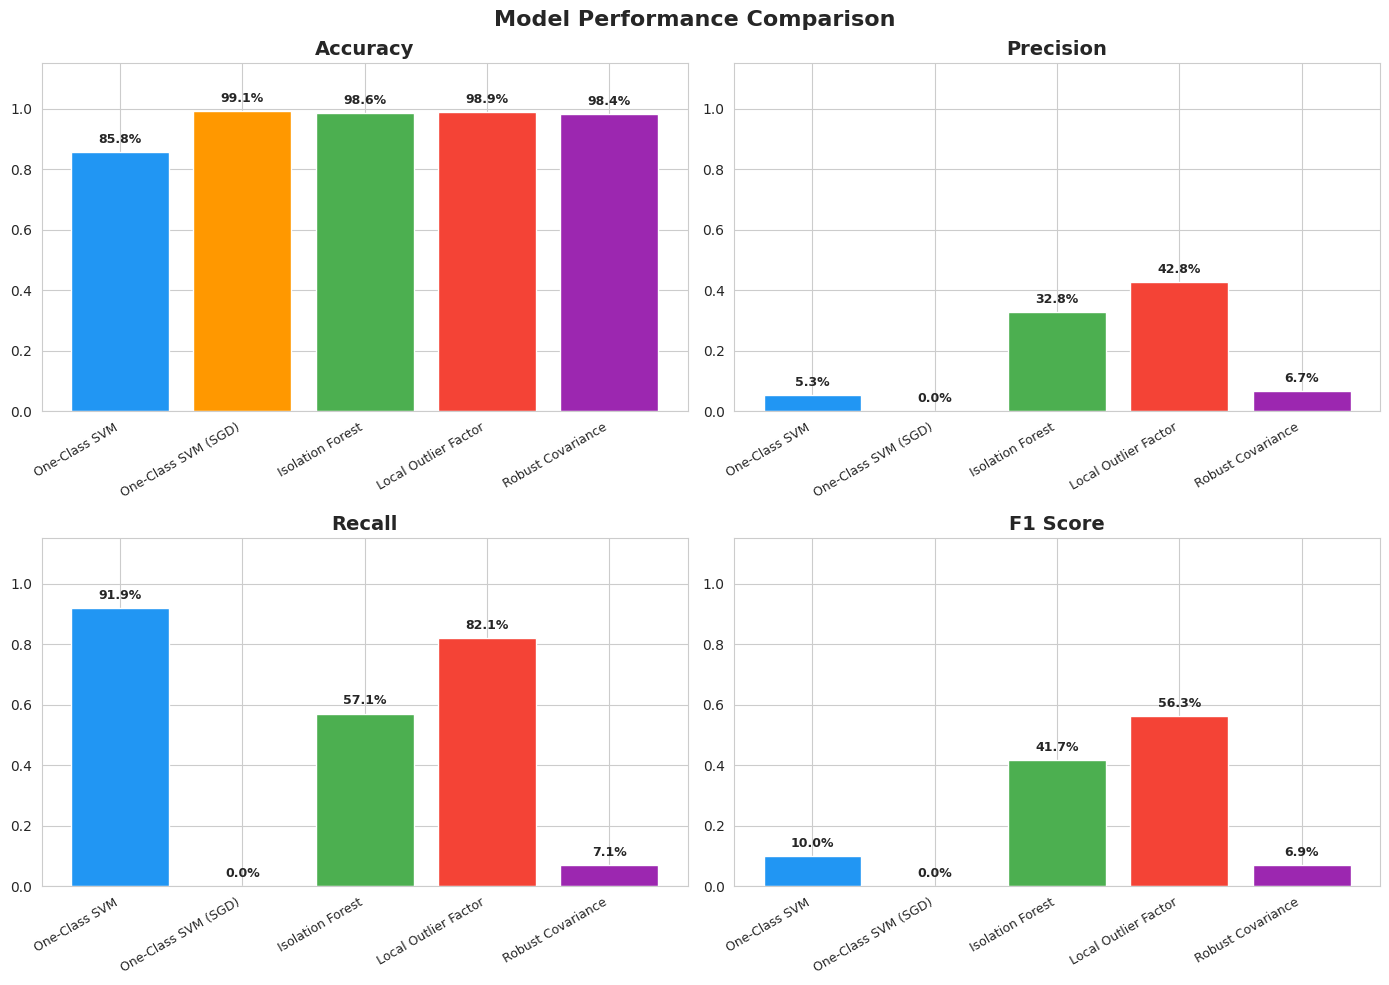

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metric_names = ["Accuracy", "Precision", "Recall", "F1 Score"]
colors = ["#2196F3", "#FF9800", "#4CAF50", "#F44336", "#9C27B0"]

for ax, metric in zip(axes.ravel(), metric_names):
    values = metrics_df[metric].values
    bars = ax.bar(range(len(metrics_df)), values, color=colors)
    ax.set_title(metric, fontsize=14, fontweight="bold")
    ax.set_ylim(0, 1.15)
    ax.set_xticks(range(len(metrics_df)))
    ax.set_xticklabels(metrics_df.index, rotation=30, ha="right", fontsize=9)
    
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f"{val:.1%}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.suptitle("Model Performance Comparison", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

### 5.2 Confusion Matrices

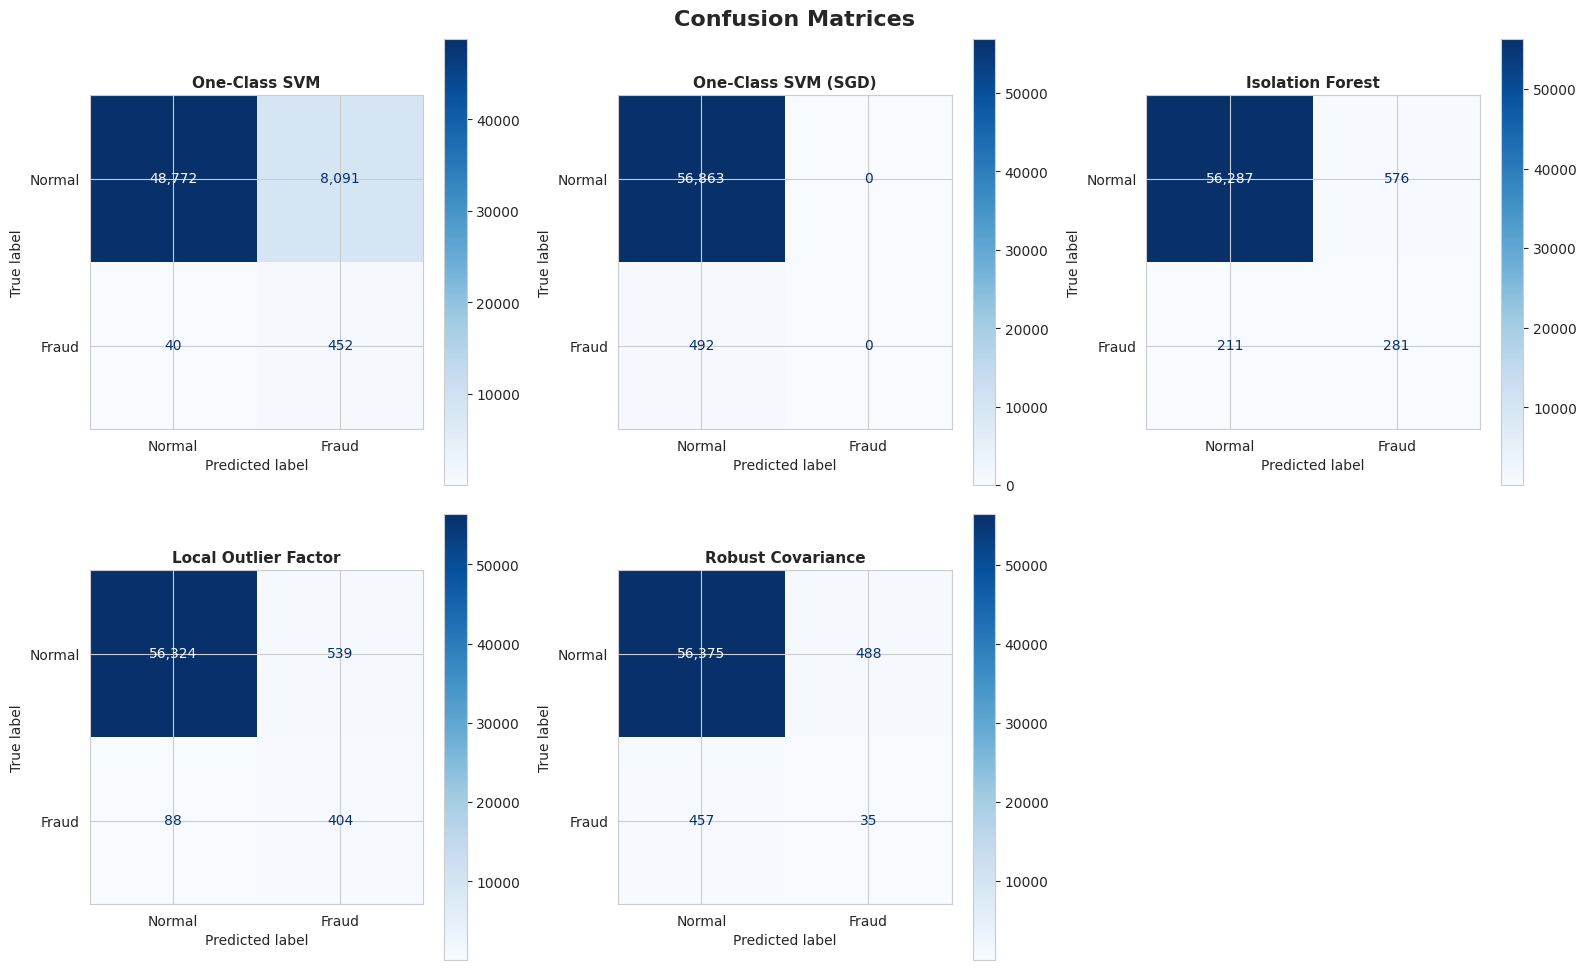

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes_flat = axes.ravel()

for i, (name, preds) in enumerate(results.items()):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Fraud"])
    disp.plot(ax=axes_flat[i], cmap="Blues", values_format=",d")
    axes_flat[i].set_title(name, fontsize=11, fontweight="bold")

# Hide empty subplot
axes_flat[5].set_visible(False)

plt.suptitle("Confusion Matrices", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

### 5.3 Computational Efficiency

Computational Efficiency:
                      Fit Time (s)  Predict Time (s)  Total (s)
One-Class SVM               0.6606            5.5244     6.1850
One-Class SVM (SGD)         1.3595            0.0248     1.3843
Isolation Forest            1.3973            0.2895     1.6867
Local Outlier Factor        0.3496            0.8555     1.2051
Robust Covariance           1.2663            0.0376     1.3039


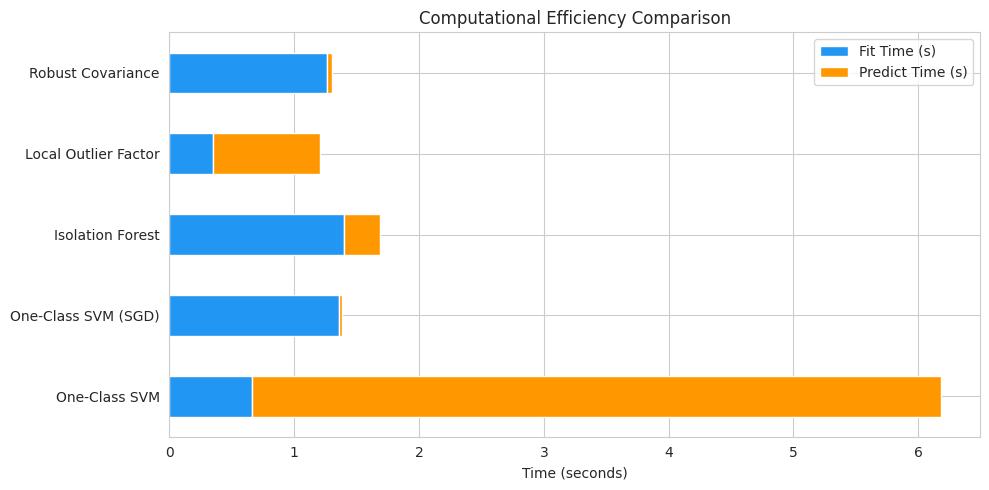

In [17]:
timing_df = pd.DataFrame(timing).T
timing_df.columns = ["Fit Time (s)", "Predict Time (s)"]
timing_df["Total (s)"] = timing_df.sum(axis=1)

print("Computational Efficiency:")
print(timing_df.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
timing_df[["Fit Time (s)", "Predict Time (s)"]].plot(
    kind="barh", stacked=True, ax=ax, color=["#2196F3", "#FF9800"]
)
ax.set_xlabel("Time (seconds)")
ax.set_title("Computational Efficiency Comparison")
plt.tight_layout()
plt.show()

### 5.4 Detailed Classification Reports

In [18]:
for name, preds in results.items():
    print(f"\n{'=' * 50}")
    print(f"{name}")
    print("=" * 50)
    print(classification_report(y_test, preds, target_names=["Normal", "Fraud"]))


One-Class SVM
              precision    recall  f1-score   support

      Normal       1.00      0.86      0.92     56863
       Fraud       0.05      0.92      0.10       492

    accuracy                           0.86     57355
   macro avg       0.53      0.89      0.51     57355
weighted avg       0.99      0.86      0.92     57355


One-Class SVM (SGD)
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00     56863
       Fraud       0.00      0.00      0.00       492

    accuracy                           0.99     57355
   macro avg       0.50      0.50      0.50     57355
weighted avg       0.98      0.99      0.99     57355


Isolation Forest
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99     56863
       Fraud       0.33      0.57      0.42       492

    accuracy                           0.99     57355
   macro avg       0.66      0.78      0.70     57355
weighted avg       0

## Summary

**What we did:**
1. Preprocessed the data (dropped Time, scaled Amount)
2. Split data: trained on normal only, tested on normal + fraud
3. Trained all 5 algorithms from the paper
4. Compared them on accuracy, precision, recall, F1 score

**Key observations:**
- Check which algorithm has the best F1 score — that's the winner
- Accuracy is high for all models because the data is so imbalanced
- The real differentiator is recall (did we catch the fraud?) vs precision (did we avoid false alarms?)
- Computational efficiency matters for real-world deployment

**For your report** — use the metrics table, bar charts, and confusion matrices in REZULTATI.  
Discuss the trade-offs between precision and recall in ZAKLJUČAK.